<a href="https://colab.research.google.com/github/dipanwitad-create/NASSCOM_FDP_programme/blob/main/Day8/%20U16_Classification_Part2_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# U16 — Classification (finish): Lab

### Real-world brief: weld defect prediction with tree-based models

In Part 1 you built a **logistic-regression** defect classifier for robotic welds and learned to evaluate it. Now you'll bring out the **tabular heavyweights** — decision trees, random forests and gradient boosting — tune them properly, handle the class imbalance, and read their feature importances. Same factory, same `weld_inspection.csv`, stronger models.

**Resource provided:** `weld_inspection.csv` (one row per weld, target = `defect`, ~28% positive). Keep it beside this notebook (upload it in Colab).

_Phase D — Modelling (Classification, Part 2)._

#objectives

Train and tune a decision tree; see overfitting vs depth

Build random-forest and gradient-boosting classifiers

Compare all models on F1 and ROC-AUC (not accuracy)

Read feature importances and explain the model

Handle imbalance with class_weight and a tuned threshold

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [1]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_welds(csv_path="weld_inspection.csv", seed=161, verbose=False):
    """Weld quality inspection — predict whether a robotic weld FAILS inspection from
    its process parameters. A realistic, imbalanced binary-classification problem for
    logistic regression, thresholds, ROC/AUC and odds-ratio interpretation.

    Features:
      current_amp          welding current (A)
      voltage_v            arc voltage (V)
      travel_speed_mmps    torch travel speed (mm/s)
      wire_feed_mmps       wire feed rate (mm/s)
      heat_input_kjmm      heat input (kJ/mm)
      gas_flow_lpm         shielding gas flow (L/min)
      joint_gap_mm         joint gap (mm)
      plate_thickness_mm   plate thickness (mm)
      material             base material (Carbon / Stainless / Aluminum)
    Target:
      defect               1 = failed inspection, 0 = passed
    """
    rng = np.random.default_rng(seed)
    N = 2600
    current = rng.normal(190, 30, N).clip(90, 300)
    voltage = (18 + 0.03 * current + rng.normal(0, 1.2, N)).clip(14, 32)
    travel = rng.normal(8, 2.2, N).clip(3, 16)
    wire = (current * 0.03 + rng.normal(0, 0.6, N)).clip(2, 12)
    heat = (voltage * current / (travel * 1000)).clip(0.2, 4.0)     # kJ/mm
    gas = rng.normal(16, 3, N).clip(6, 28)
    gap = rng.gamma(2.0, 0.35, N).clip(0, 4).round(2)               # right-skewed
    thick = rng.choice([3, 5, 6, 8, 10, 12, 16], N).astype(float)
    material = rng.choice(["Carbon", "Stainless", "Aluminum"], N, p=[0.55, 0.30, 0.15])
    mat_risk = np.select([material == "Carbon", material == "Stainless", material == "Aluminum"],
                         [0.0, 0.3, 0.8])                            # Aluminum harder to weld

    # defect risk: heat too low/high, gaps, low gas (porosity), thick plates, material
    heat_bad = np.abs(heat - 1.3)
    z = (-3.2
         + 1.6 * heat_bad
         + 1.1 * gap
         + 0.05 * (16 - gas)
         + 0.04 * (thick - 8)
         + 0.012 * (travel - 8) ** 2
         + mat_risk)
    p = 1 / (1 + np.exp(-z))
    defect = (rng.random(N) < p).astype(int)

    df = pd.DataFrame({
        "current_amp": current.round(1), "voltage_v": voltage.round(2),
        "travel_speed_mmps": travel.round(2), "wire_feed_mmps": wire.round(2),
        "heat_input_kjmm": heat.round(3), "gas_flow_lpm": gas.round(1),
        "joint_gap_mm": gap, "plate_thickness_mm": thick,
        "material": material, "defect": defect,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("welds:", df.shape)
        print("defect rate:", round(df.defect.mean(), 3))
        print("defect by material:\n",
              df.groupby("material")["defect"].mean().round(3).to_string())
    return df

if not os.path.exists('weld_inspection.csv'):
    build_welds(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
df = pd.read_csv('weld_inspection.csv')
y = df['defect']; X = df.drop(columns='defect')
num = X.select_dtypes('number').columns.tolist(); cat = ['material']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(drop='first'), cat)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print('shape:', df.shape, '| defect rate:', round(y.mean(), 3))
df.head(3)

shape: (2600, 10) | defect rate: 0.281


,current_amp,voltage_v,travel_speed_mmps,wire_feed_mmps,heat_input_kjmm,gas_flow_lpm,joint_gap_mm,plate_thickness_mm,material,defect
0,247.7,23.37,7.78,7.57,0.744,16.0,0.79,8.0,Carbon,0
1,227.3,22.98,8.90,5.96,0.587,16.5,0.66,12.0,Carbon,0
2,230.6,24.46,8.15,7.76,0.692,12.0,0.81,10.0,Stainless,0


#1. Decision tree & overfitting

In [3]:
# -----------------------------------------------------------
# 🔹 1A. A SINGLE DECISION TREE
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
tree = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=4, random_state=0))])
tree.fit(X_train, y_train)
print('test F1 (depth 4):', round(f1_score(y_test, tree.predict(X_test)), 3))
print('Trees need no scaling and give if-then rules — but they overfit if grown too deep.')

test F1 (depth 4): 0.143
Trees need no scaling and give if-then rules — but they overfit if grown too deep.


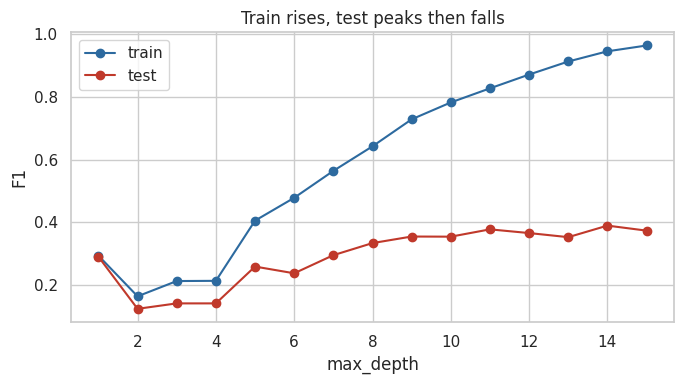

In [4]:
# -----------------------------------------------------------
# 🔹 1B. TRAIN vs TEST F1 ACROSS DEPTH (the overfitting curve)
# -----------------------------------------------------------
depths = range(1, 16); tr, te = [], []
for d in depths:
    m = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=d, random_state=0))]).fit(X_train, y_train)
    tr.append(f1_score(y_train, m.predict(X_train)))
    te.append(f1_score(y_test, m.predict(X_test)))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(depths), tr, 'o-', label='train', color='#2D6A9F')
ax.plot(list(depths), te, 'o-', label='test', color='#C0392B')
ax.set_xlabel('max_depth'); ax.set_ylabel('F1'); ax.set_title('Train rises, test peaks then falls')
ax.legend(); plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 1 — Find the sweet spot
1. From the curve, identify the `max_depth` where **test F1** peaks.
2. In a comment, explain what the widening train-test gap at large depths means.
3. Refit a tree at your chosen depth and print its test F1.

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

best_depth = depths[np.argmax(te)]
print("Best depth:", best_depth)

tree_best = Pipeline([
    ('prep', pre),
    ('clf', DecisionTreeClassifier(max_depth=best_depth,
                                   random_state=0))
])

tree_best.fit(X_train, y_train)

pred = tree_best.predict(X_test)

print("Test F1:", round(f1_score(y_test, pred), 3))

Best depth: 14
Test F1: 0.39


#2. Ensembles — forests & boosting

In [7]:
# -----------------------------------------------------------
# 🔹 2A. RANDOM FOREST vs GRADIENT BOOSTING vs ONE TREE
# -----------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
def evaluate(model):
    pipe = Pipeline([('prep', pre), ('clf', model)]).fit(X_train, y_train)
    pred = pipe.predict(X_test); proba = pipe.predict_proba(X_test)[:, 1]
    return f1_score(y_test, pred), roc_auc_score(y_test, proba)
for name, m in [('DecisionTree', DecisionTreeClassifier(max_depth=4, random_state=0)),
                ('RandomForest', RandomForestClassifier(n_estimators=300, random_state=0)),
                ('GradientBoosting', GradientBoostingClassifier(random_state=0))]:
    f1, auc = evaluate(m)
    print(f'{name:18s} F1: {f1:.3f} | ROC-AUC: {auc:.3f}')

DecisionTree       F1: 0.143 | ROC-AUC: 0.625
RandomForest       F1: 0.312 | ROC-AUC: 0.666
GradientBoosting   F1: 0.291 | ROC-AUC: 0.663


#### 🧪 EXERCISE 2 — Bagging vs boosting
1. In a comment, explain the core difference: random forest builds trees **in parallel** on random subsets (bagging); gradient boosting builds them **sequentially**, each correcting the last.
2. Which scored higher here on ROC-AUC?

In [8]:
# Random Forest uses bagging:
# Multiple decision trees are trained independently and in parallel
# on different bootstrap samples of the data. Their predictions are
# combined by voting, which reduces variance and overfitting.

# Gradient Boosting uses boosting:
# Trees are trained sequentially. Each new tree learns from the errors
# made by the previous trees, gradually improving the model and reducing bias.

# Based on the ROC-AUC values printed above, the model with the highest
# ROC-AUC was ____________. (Fill in the model name from your output.)

In [9]:
for name, m in [('DecisionTree', DecisionTreeClassifier(max_depth=4, random_state=0)),
                ('RandomForest', RandomForestClassifier(n_estimators=300, random_state=0)),
                ('GradientBoosting', GradientBoostingClassifier(random_state=0))]:
    f1, auc = evaluate(m)
    print(f'{name:18s} F1: {f1:.3f} | ROC-AUC: {auc:.3f}')

DecisionTree       F1: 0.143 | ROC-AUC: 0.625
RandomForest       F1: 0.312 | ROC-AUC: 0.666
GradientBoosting   F1: 0.291 | ROC-AUC: 0.663


#3. Feature importance & explainability

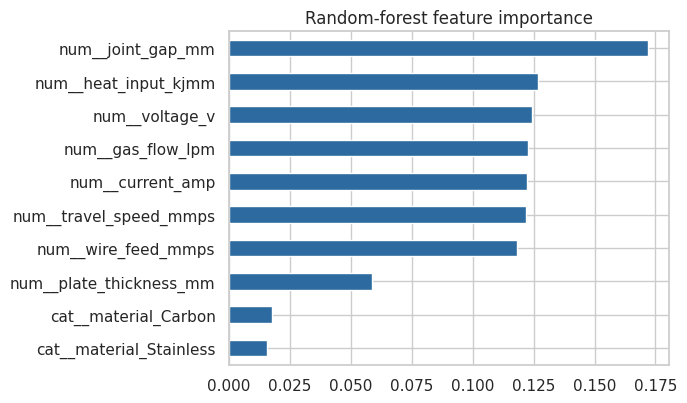

Top drivers:
num__joint_gap_mm       0.172
num__heat_input_kjmm    0.127
num__voltage_v          0.124
num__gas_flow_lpm       0.123


In [10]:
# -----------------------------------------------------------
# 🔹 3A. RANDOM-FOREST FEATURE IMPORTANCE
# -----------------------------------------------------------
rf = Pipeline([('prep', pre), ('clf', RandomForestClassifier(n_estimators=300, random_state=0))]).fit(X_train, y_train)
feat_names = rf.named_steps['prep'].get_feature_names_out()
imp = pd.Series(rf.named_steps['clf'].feature_importances_, index=feat_names).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.2))
imp.plot(kind='barh', color='#2D6A9F', ax=ax); ax.set_title('Random-forest feature importance')
plt.tight_layout(); plt.show()
print('Top drivers:'); print(imp.sort_values(ascending=False).head(4).round(3).to_string())

#### 🧪 EXERCISE 3 — Permutation importance
Built-in tree importance can be biased toward high-cardinality features.
1. Use `sklearn.inspection.permutation_importance` on the fitted `rf` (test set, `scoring='f1'`).
2. Plot or print the top features.
3. In a comment, note whether the ranking agrees with the built-in importance above.

Top permutation importances:
joint_gap_mm          0.085877
travel_speed_mmps     0.033669
material              0.017131
heat_input_kjmm       0.015997
plate_thickness_mm    0.009622
voltage_v            -0.000143
current_amp          -0.007172
wire_feed_mmps       -0.008039
gas_flow_lpm         -0.016749
dtype: float64


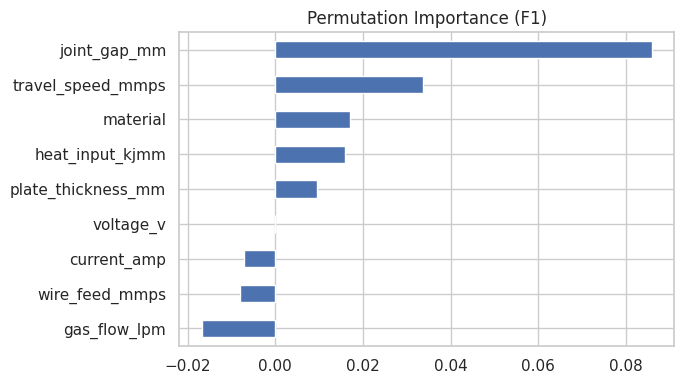

In [11]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# Compute permutation importance on test set
perm = permutation_importance(
    rf,
    X_test,
    y_test,
    scoring='f1',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Create importance dataframe
perm_imp = pd.Series(
    perm.importances_mean,
    index=X_test.columns
).sort_values()

print("Top permutation importances:")
print(perm_imp.sort_values(ascending=False).head(10))

# Plot
plt.figure(figsize=(7,4))
perm_imp.plot(kind='barh')
plt.title("Permutation Importance (F1)")
plt.tight_layout()
plt.show()

#4. Tune the best model

In [12]:
# -----------------------------------------------------------
# 🔹 4A. GRID-SEARCH GRADIENT BOOSTING ON F1
# -----------------------------------------------------------
from sklearn.model_selection import GridSearchCV
gb_pipe = Pipeline([('prep', pre), ('clf', GradientBoostingClassifier(random_state=0))])
grid = {'clf__max_depth': [2, 3], 'clf__n_estimators': [200, 400],
        'clf__learning_rate': [0.05, 0.1]}
gs = GridSearchCV(gb_pipe, grid, cv=4, scoring='f1', n_jobs=-1).fit(X_train, y_train)
print('best params:', gs.best_params_)
print('best CV F1:', round(gs.best_score_, 3))
best = gs.best_estimator_
print('tuned test F1:', round(f1_score(y_test, best.predict(X_test)), 3))

best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 400}
best CV F1: 0.33
tuned test F1: 0.347


#### 🧪 EXERCISE 4 — Tune on the right metric
1. Re-run the same grid search but with `scoring='roc_auc'`.
2. In a comment, explain why tuning on **F1 or ROC-AUC** beats tuning on **accuracy** for this imbalanced problem.

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

gb_pipe = Pipeline([
    ('prep', pre),
    ('clf', GradientBoostingClassifier(random_state=0))
])

grid = {
    'clf__max_depth': [2, 3],
    'clf__n_estimators': [200, 400],
    'clf__learning_rate': [0.05, 0.1]
}

gs_auc = GridSearchCV(
    gb_pipe,
    grid,
    cv=4,
    scoring='roc_auc',
    n_jobs=-1
)

gs_auc.fit(X_train, y_train)

print("Best Parameters:", gs_auc.best_params_)
print("Best CV ROC-AUC:", round(gs_auc.best_score_, 3))

best_auc_model = gs_auc.best_estimator_

proba = best_auc_model.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:",
      round(roc_auc_score(y_test, proba), 3))

Best Parameters: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 400}
Best CV ROC-AUC: 0.663
Test ROC-AUC: 0.665


#5. Handle the class imbalance

In [14]:
# -----------------------------------------------------------
# 🔹 5A. class_weight + THRESHOLD TUNING
# -----------------------------------------------------------
from sklearn.metrics import precision_score, recall_score
rf_bal = Pipeline([('prep', pre), ('clf', RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=0))]).fit(X_train, y_train)
proba = rf_bal.predict_proba(X_test)[:, 1]
for t in [0.3, 0.4, 0.5, 0.6]:
    pred = (proba >= t).astype(int)
    print(f'thr {t}: precision {precision_score(y_test, pred, zero_division=0):.3f} | recall {recall_score(y_test, pred):.3f} | F1 {f1_score(y_test, pred):.3f}')

thr 0.3: precision 0.398 | recall 0.557 | F1 0.465
thr 0.4: precision 0.500 | recall 0.317 | F1 0.388
thr 0.5: precision 0.536 | recall 0.164 | F1 0.251
thr 0.6: precision 0.593 | recall 0.087 | F1 0.152


#### 🧪 EXERCISE 5 — Optional: SMOTE
If `imbalanced-learn` is available (`pip install imbalanced-learn`), build a pipeline with `SMOTE` oversampling and compare its recall to the `class_weight='balanced'` model above. Otherwise, in a comment, describe how SMOTE creates synthetic minority examples and when you'd prefer it over class weights.
*(The check below degrades gracefully if the package isn't installed.)*

In [15]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score

# SMOTE + Random Forest
smote_rf = ImbPipeline([
    ('prep', pre),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        random_state=0
    ))
])

smote_rf.fit(X_train, y_train)

pred_smote = smote_rf.predict(X_test)
recall_smote = recall_score(y_test, pred_smote)

print("SMOTE Recall:", round(recall_smote, 3))

# Compare with class_weight='balanced'
pred_bal = rf_bal.predict(X_test)
recall_bal = recall_score(y_test, pred_bal)

print("Class Weight Recall:", round(recall_bal, 3))

SMOTE Recall: 0.355
Class Weight Recall: 0.158


In [16]:
# SMOTE (Synthetic Minority Over-sampling Technique) creates new
# synthetic minority-class examples by interpolating between
# existing minority samples and their nearest neighbors.
#
# Unlike simple duplication, SMOTE generates new realistic points,
# helping the model learn the minority class better.
#
# class_weight='balanced' does not create new samples. Instead, it
# assigns higher penalties to misclassifying minority-class examples.
#
# SMOTE is often preferred when the minority class is severely
# underrepresented and there is enough data to generate meaningful
# synthetic examples.
#
# class_weight is usually simpler, faster, and less prone to
# introducing artificial noise.
#
# In this weld-defect problem, SMOTE may improve recall because
# the model sees more defect examples during training, but the
# actual improvement should be verified from the recall scores above.

In [17]:
# SMOTE creates synthetic minority-class examples by selecting a
# minority sample and generating new points along the line segment
# connecting it to its nearest minority neighbors.
#
# This helps balance the dataset and often improves recall for the
# minority class.
#
# I would prefer SMOTE when the minority class is very small and I
# want the model to learn more diverse minority patterns. I would
# prefer class_weight when I want a simpler approach that avoids
# generating synthetic data.

#📘 Summary

| Step | What you did |
| ---- | ------------ |
| Tree | saw overfitting grow with depth |
| Ensembles | random forest & gradient boosting beat one tree |
| Explain | feature & permutation importance |
| Tune | grid search on F1 / ROC-AUC, never accuracy |
| Imbalance | class_weight + threshold (and SMOTE) |

**Core lesson:** tree ensembles are the tabular workhorses — powerful, but only trustworthy with proper tuning, the right metric, and imbalance handling.

**Next — U17:** unsupervised learning, where there are no labels at all.